# EDA

In [21]:
import pandas as pd

data = pd.read_csv('seeds.csv')
data

,area,perimeter,compactness,len_ker,wid_ker,a_coef,len_ker_gro,label
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


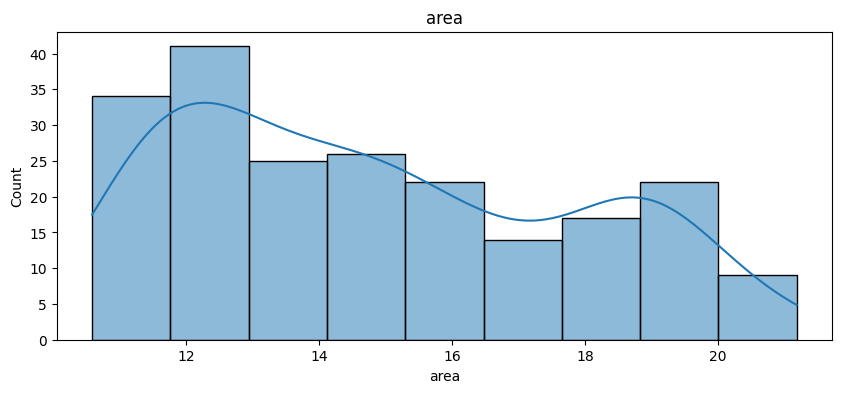

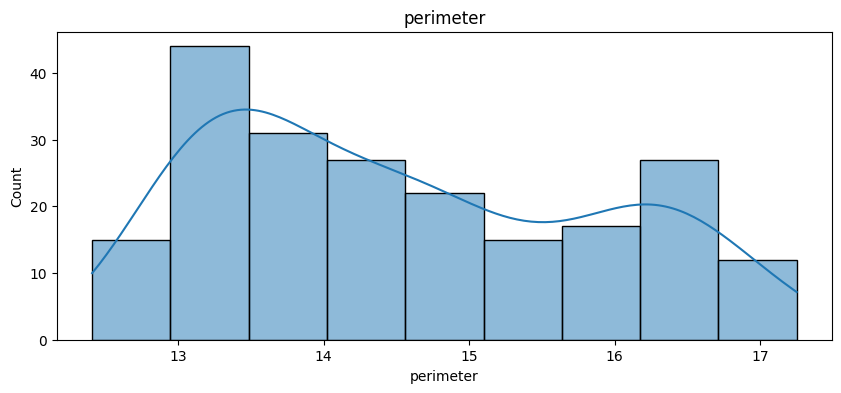

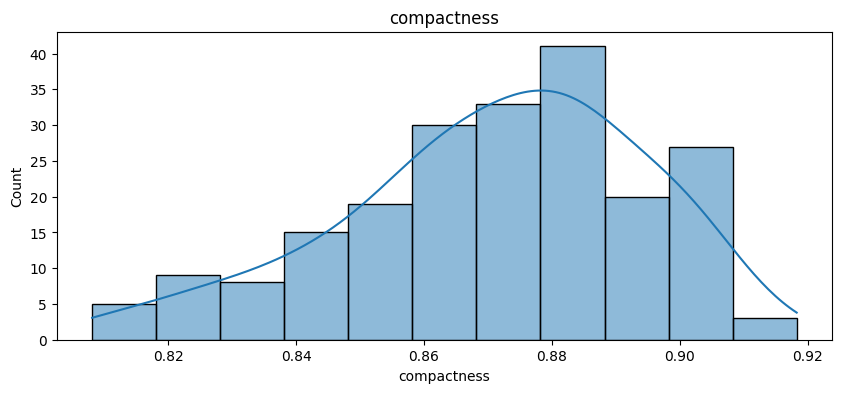

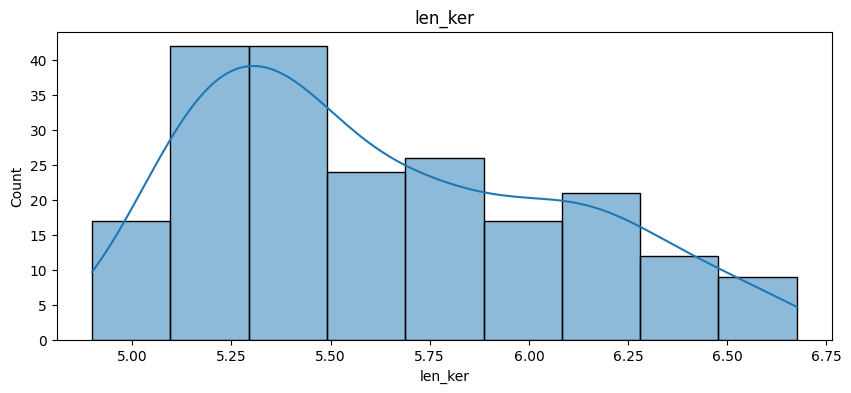

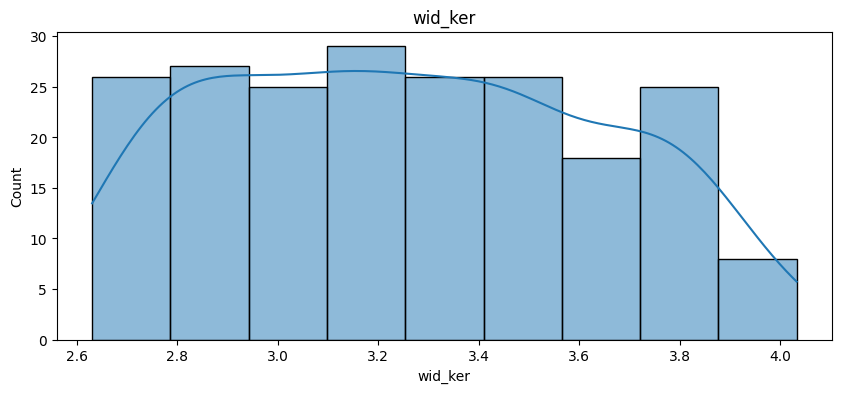

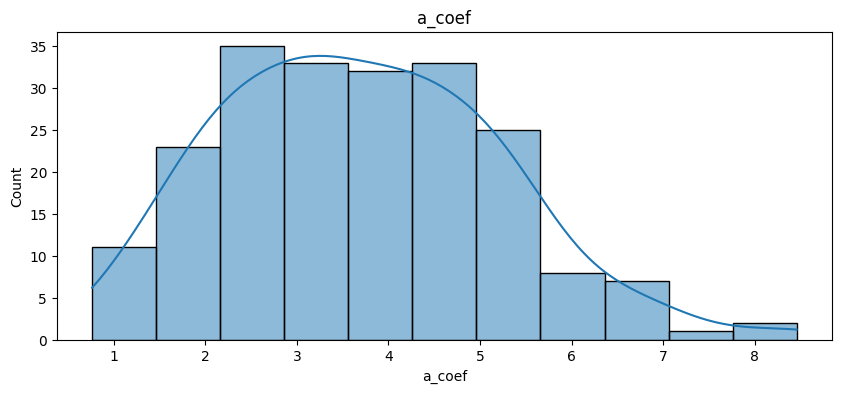

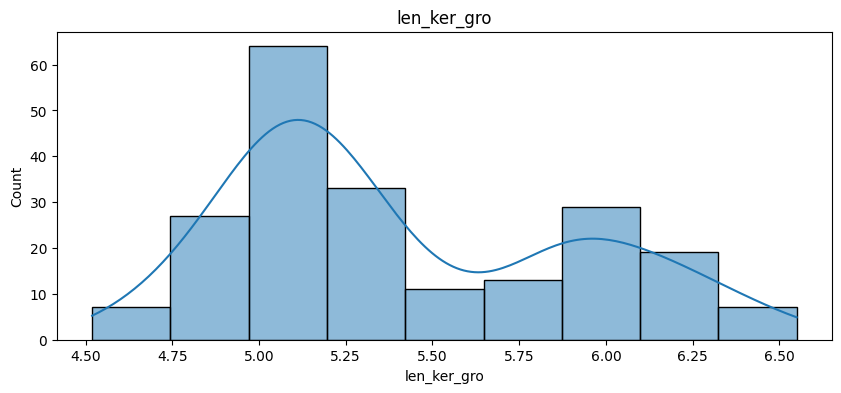

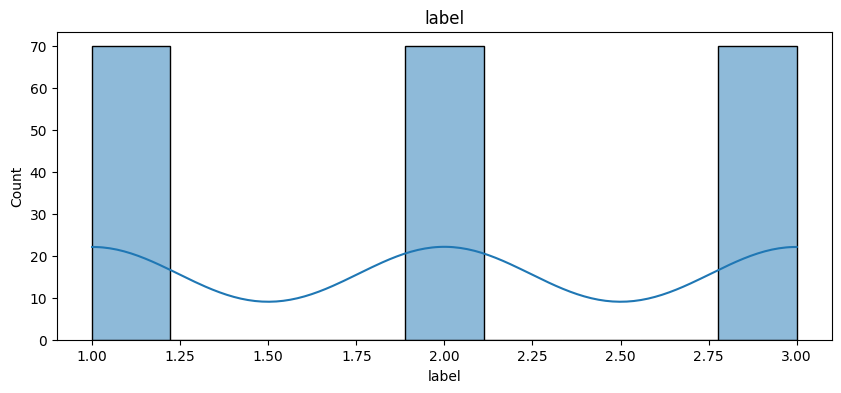

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in data.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

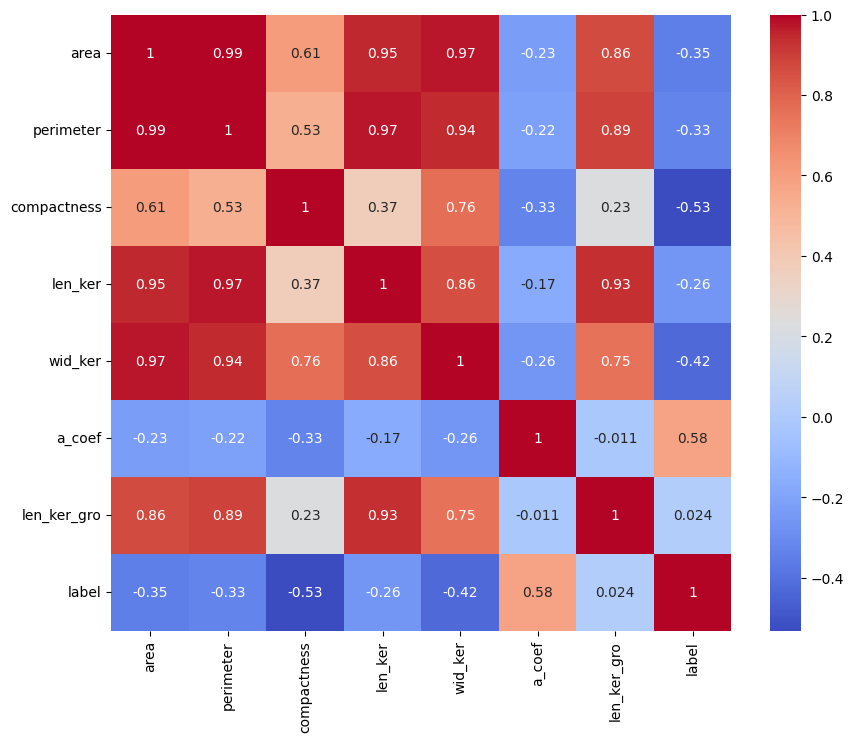

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

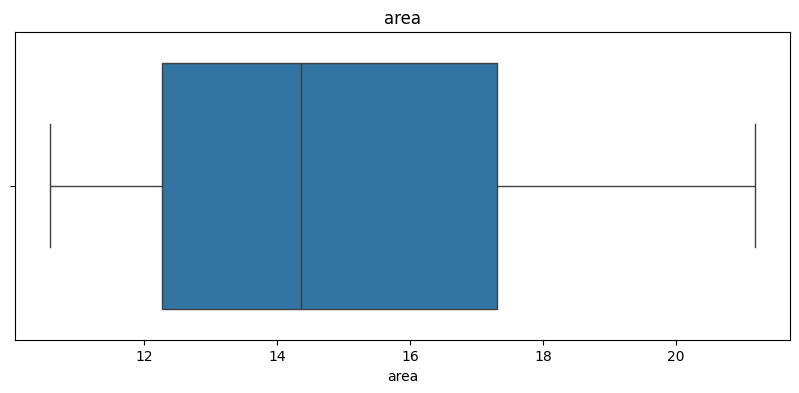

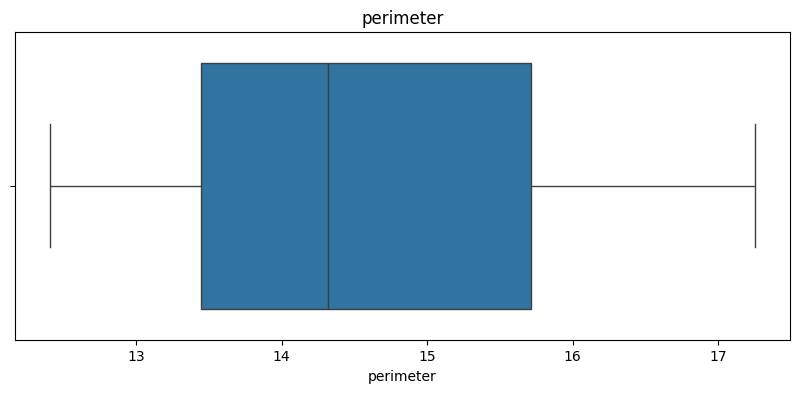

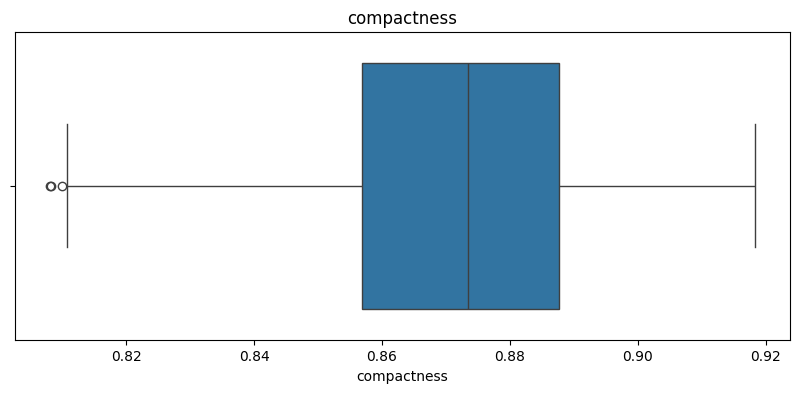

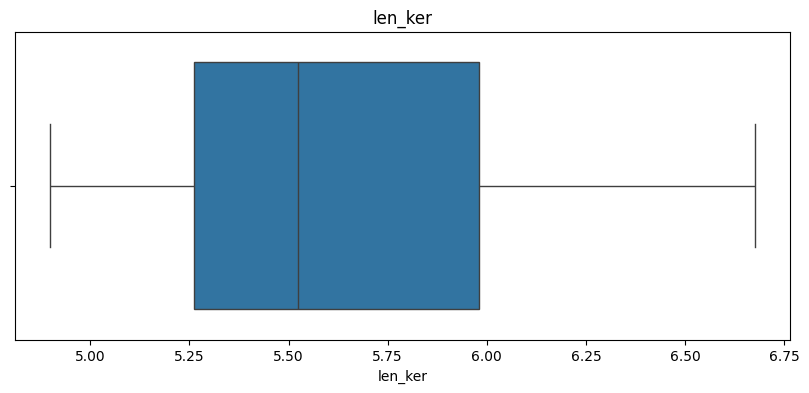

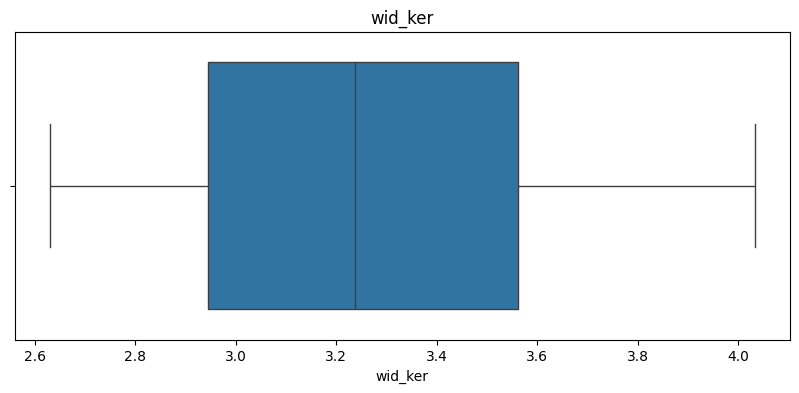

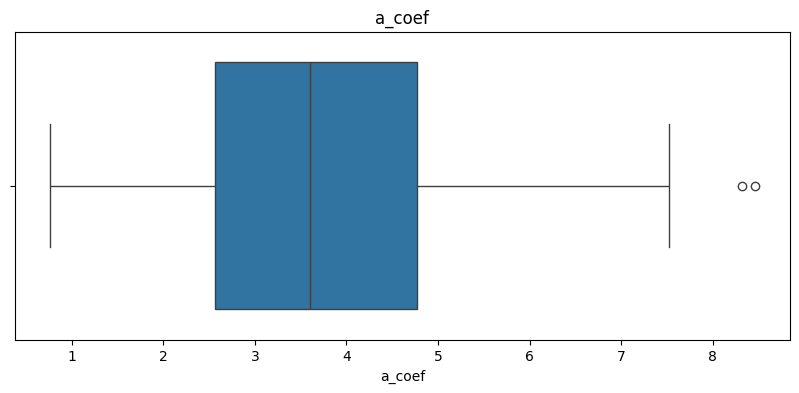

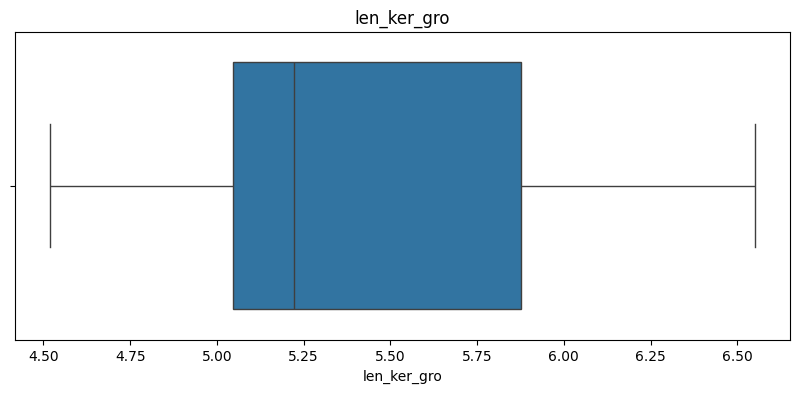

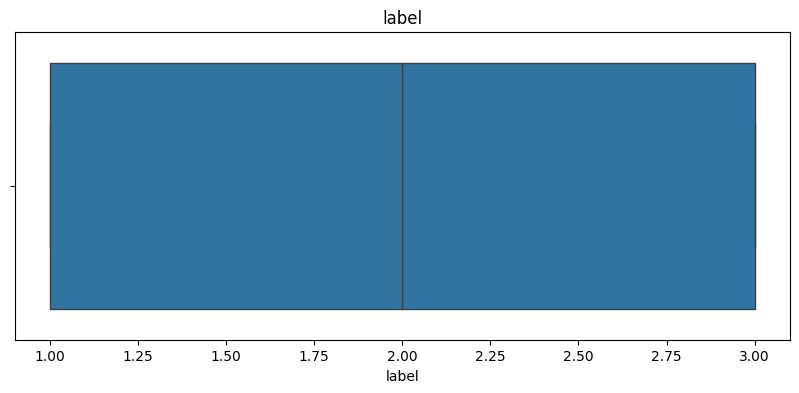

In [24]:
for col in data.columns:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

# TODO_1

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [26]:
data = pd.read_csv('seeds.csv')
data

,area,perimeter,compactness,len_ker,wid_ker,a_coef,len_ker_gro,label
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


In [27]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.iloc[:, :-1])

In [28]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

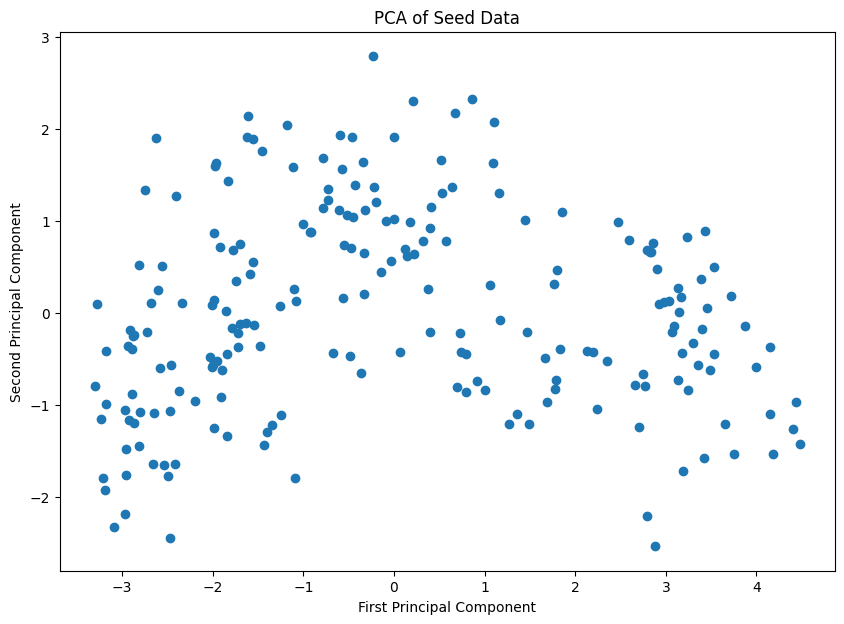

In [29]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_data[:, 0], pca_data[:, 1])
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA of Seed Data')
plt.show()

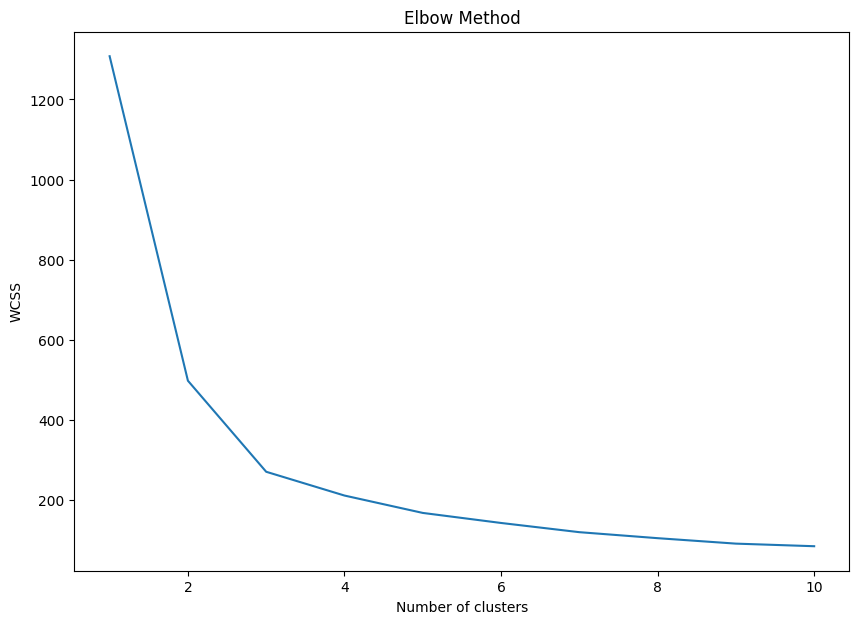

In [30]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10, 7))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [31]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
clusters = kmeans.fit_predict(pca_data)

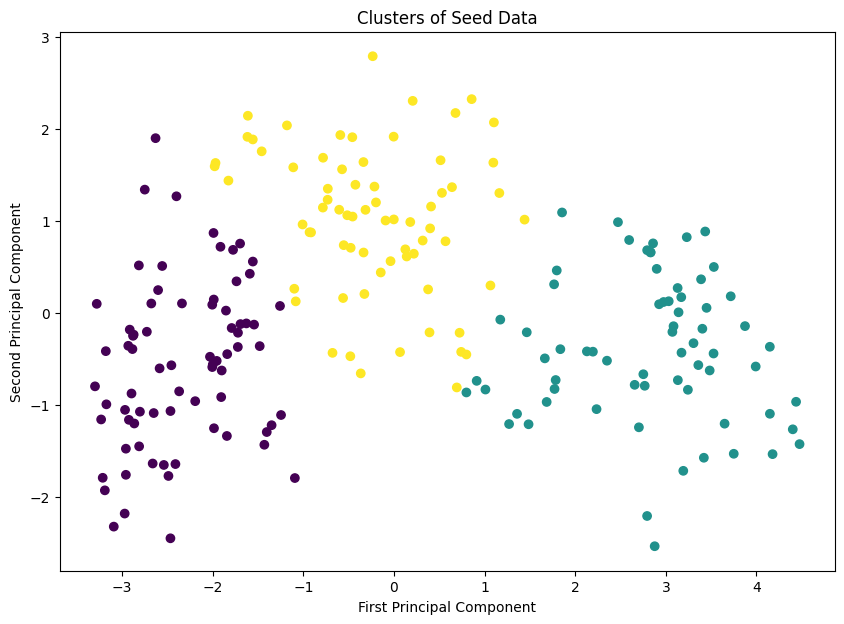

In [32]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Clusters of Seed Data')
plt.show()

# TODO_2

In [33]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [34]:
data = pd.read_csv('seeds.csv')
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_lin = mean_squared_error(y_test, y_pred_lin)

print(f'Ridge Regression MSE: {mse_ridge}')
print(f'Linear Regression MSE: {mse_lin}')

Ridge Regression MSE: 0.15373961436192238
Linear Regression MSE: 0.10513096161958131


In [36]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=1.0)
lasso_reg.fit(X_train, y_train)
y_pred_lasso = lasso_reg.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print(f'Lasso Regression MSE: {mse_lasso}')

Lasso Regression MSE: 0.6190476190476191


In [37]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd

# 데이터 로드 및 전처리
data = pd.read_csv('seeds.csv')
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Ridge Regression 모델 학습 함수: alpha 값을 인자로 받음
def train_ridge_regression(alpha_value):
    ridge_reg = Ridge(alpha=alpha_value)
    ridge_reg.fit(X_train, y_train)
    y_pred_ridge = ridge_reg.predict(X_test)
    mse_ridge = mean_squared_error(y_test, y_pred_ridge)
    return mse_ridge

# Linear Regression 모델 학습 및 성능 평가
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)
mse_lin = mean_squared_error(y_test, y_pred_lin)

# Ridge Regression의 성능 평가: 여러 alpha 값에 대해 MSE 계산
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]
for alpha_value in alpha_values:
    mse_ridge = train_ridge_regression(alpha_value)
    print(f'Ridge Regression MSE with alpha={alpha_value}: {mse_ridge}')

print(f'Linear Regression MSE: {mse_lin}')


Ridge Regression MSE with alpha=0.01: 0.12374449770455084
Ridge Regression MSE with alpha=0.1: 0.13976003958927766
Ridge Regression MSE with alpha=1.0: 0.15373961436192238
Ridge Regression MSE with alpha=10.0: 0.23390553556407861
Ridge Regression MSE with alpha=100.0: 0.3403491643625537
Linear Regression MSE: 0.10513096161958131
